# Logistic Regression Code Goes Here

In [15]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MaxAbsScaler

In [8]:
def make_bow(df):
    text = df['text']
    y_scores = df['label']

    # Add the line break character to the list of stop words.
    sw = list(ENGLISH_STOP_WORDS.union(["br"]))

    # Create a vectorizer that considers bigrams, just to see what happens.
    # I imagine that movie reviewers might use certain phrases to describe
    # their sentiment, and that's important to consider in classification.
    vectorizer = CountVectorizer(stop_words = sw, min_df = 0.0, ngram_range = (1, 2))

    # Note that <fit_transform> returns a sparse matrix.
    X_bow = vectorizer.fit_transform(text)

    # Scale down the training data.
    scaler = MaxAbsScaler()
    X_bow_scaled = scaler.fit_transform(X_bow)

    return X_bow_scaled, y_scores, vectorizer, scaler, text

In [9]:
# Read the training data into a Pandas dataframe.
# Partitioning of data was done prior to reading.
df_tr = pd.read_parquet("../data/train.parquet")

# Process the training data into a bag of words representation.
X_tr, y_tr, vectorizer, scaler, text = make_bow(df_tr)

# Read and transform the testing data.
df_te = pd.read_parquet("../data/test.parquet")
X_te = vectorizer.transform(df_te['text'])

# Scale down the testing data.
X_te = scaler.transform(X_te)
y_te = df_te['label']

In [10]:
classifier = LogisticRegression(penalty = 'l1', solver = 'liblinear', max_iter = 100)
classifier.fit(X_tr, y_tr)

pred = classifier.predict(X_te)
acc = classifier.score(X_te, y_te) * 100

print("TESTING ACCURACY: ", format(acc, '.2f'))


TESTING ACCURACY W/ UNMODIFIED HYPERPARAMETERS: 87.41


8595
better with min df

86.58
better with higher ngram range

88 with l2 and sag

87.41 vs 87.65 for ngram ranges

66.84 because of min df of 0.2
ooops

doesn't really care about the line breaks

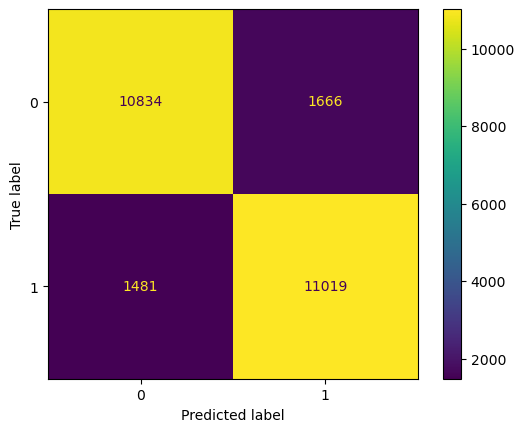

In [20]:
m = confusion_matrix(y_te, pred)
_ = ConfusionMatrixDisplay(m).from_predictions(y_te, pred)

In [24]:
precision = 11019 /  (11019 + 1666)
recall = 11019 / (11019 + 1481)
print(f"PRECISION: {precision}")
print(f"RECALL: {recall}")


PRECISION (catching positives): 0.8686637761135199
RECALL (catching negatives): 0.88152
